# Insurance Pricing Optimization – Full Cost Function (QUBO Form)

---

## Decision Variables

We define binary variables:

$$
x_{i,j} \in \{0,1\}
$$

- \( x_{i,j} = 1 \) if we choose price level \( j \) for segment \( i \)
- \( i = 1,\dots,N \) (segments / customers)
- \( j = 1,\dots,K \) (price levels)

---

## Acceptance Probability (Price Elasticity)

The probability that a customer in segment \( i \) accepts price \( P_{i,j} \):

$$
q(P_{i,j}) = \frac{1}{1 + e^{\beta_i (P_{i,j} - B_i)}}
$$

with:

$$
B_i = \text{IncomeLevel}_i \cdot \text{BF}
$$

Normalized income:

$$
\text{NormIncome}_i =
\frac{\text{IncomeLevel}_i - \text{MinIncome}}
{\text{MaxIncome} - \text{MinIncome}}
$$

Elasticity parameter:

$$
\beta_i =
\frac{1}{\text{ScalingFactor} \cdot (1 + \text{NormIncome}_i)}
$$

---

## Expected Loss

Expected loss per segment:

$$
L_i =
\text{CoverageAmount}_i \cdot 0.005 \cdot (1 + S_i)
$$

Risk score:

$$
S_i =
\frac{1}{2}
\left(
\frac{\text{RiskProfile}_i}{3}
+
\frac{\text{PreviousClaims}_i}{3}
\right)
$$

---

## Expected Margin

Expected margin if price \( P_{i,j} \) is chosen:

$$
M_{i,j} =
q(P_{i,j}) \cdot (P_{i,j} - L_i)
$$

---

## Profit Term (We Minimize Negative Profit)

$$
H_{\text{profit}}
=
-
\sum_{i=1}^N
\sum_{j=1}^K
M_{i,j} \, x_{i,j}
$$

---

## Selection Constraint (One Price Per Segment)

To enforce that exactly one price is selected per segment:

$$
H_{\text{selection}}
=
\lambda_1
\sum_{i=1}^N
\left(
\sum_{j=1}^K x_{i,j} - 1
\right)^2
$$

This penalizes selecting multiple prices or no price.

---

## Full Optimization Objective

The total cost function is:

$$
H(x)
=
-
\sum_{i=1}^N
\sum_{j=1}^K
q(P_{i,j}) (P_{i,j} - L_i) x_{i,j}
+
\lambda_1
\sum_{i=1}^N
\left(
\sum_{j=1}^K x_{i,j} - 1
\right)^2
$$

---

## QUBO Structure

Since all pricing, elasticity, and loss terms are data-dependent constants, the optimization reduces to a quadratic form in binary variables:

$$
H(x) =
\sum_{i,j} a_{i,j} x_{i,j}
+
\sum_{i,j<k} b_{i,j,k} x_{i,j} x_{i,k}
$$

This is a **pure QUBO problem**, suitable for:

- QAOA (Quantum Approximate Optimization Algorithm)
- Ising mapping
- Simulated Annealing
- Classical QUBO solvers

---

## Mapping to Ising (Quantum Form)

Binary-to-spin transformation:

$$
x_{i,j} = \frac{1 - Z_{i,j}}{2}
$$

This yields a Hamiltonian of the form:

$$
H_C =
\sum h_{i,j} Z_{i,j}
+
\sum J_{(i,j)(k,l)} Z_{i,j} Z_{k,l}
$$

which can be directly implemented in QAOA.

# From Insurance Pricing Objective → QUBO Matrix $Q$ → Exact Ising Hamiltonian

Below is the **explicit $Q$ matrix structure** for the pricing objective, followed by the **exact Ising form** obtained after the transformation  
$$
x = \frac{1 - Z}{2}.
$$

This presentation is general and directly usable for implementation.

---

# 1) Flatten the Variables

We start with binary variables:

$$
x_{i,j}, \quad i=1,\dots,N, \; j=1,\dots,K.
$$

To build a QUBO matrix, we flatten the 2D index into a 1D index:

$$
t = \mathrm{idx}(i,j) = (i-1)K + (j-1),
$$

so that

$$
x_t \equiv x_{i,j}.
$$

The total number of binary variables is:

$$
n = N K.
$$

Each flattened variable corresponds to one qubit in QAOA.

---

# 2) Cost Function in QUBO Form

The optimization objective is:

$$
H(x)=
-\sum_{i=1}^{N}\sum_{j=1}^{K} M_{i,j}\, x_{i,j}
+
\lambda_1 \sum_{i=1}^{N}\Big(\sum_{j=1}^{K}x_{i,j}-1\Big)^2.
$$

where

$$
M_{i,j}=q(P_{i,j})\,(P_{i,j}-L_i)
$$

is a constant computed from the dataset.

The first term maximizes expected profit.  
The second term enforces the **one-hot constraint** (exactly one price per customer).

---

# 3) Expand the One-Hot Constraint

For a fixed customer $i$, define:

$$
s_i = \sum_{j=1}^{K} x_{i,j}.
$$

Then:

$$
(s_i - 1)^2 = s_i^2 - 2 s_i + 1.
$$

Since variables are binary,

$$
x_{i,j}^2 = x_{i,j},
$$

we expand:

$$
s_i^2 =
\left(\sum_j x_{i,j}\right)^2
=
\sum_j x_{i,j}
+
2\sum_{j<k} x_{i,j}x_{i,k}.
$$

Therefore,

$$
(s_i - 1)^2
=
-\sum_j x_{i,j}
+
2\sum_{j<k} x_{i,j}x_{i,k}
+
1.
$$

Plugging into the objective:

$$
H(x)
=
\sum_{i,j}\big(-M_{i,j}-\lambda_1\big)x_{i,j}
+
2\lambda_1 \sum_i \sum_{j<k} x_{i,j}x_{i,k}
+
\lambda_1 N.
$$

The term $\lambda_1 N$ is constant and does not affect the optimizer.

---

# 4) Explicit $Q$ Matrix Structure

We want:

$$
H(x) = x^\top Q x + \text{const}.
$$

Convention used in QUBO:

- Linear coefficients go on the diagonal: $Q_{tt}$ multiplies $x_t$
- For quadratic term $c x_u x_v$, we set
  $$
  Q_{uv} = Q_{vu} = \frac{c}{2}
  $$
  because
  $$
  x^\top Q x \supset 2Q_{uv} x_u x_v.
  $$

---

## 4.1 Diagonal Entries

For each variable $t = \mathrm{idx}(i,j)$:

$$
Q_{tt} = -M_{i,j} - \lambda_1.
$$

---

## 4.2 Off-Diagonal Entries

Quadratic terms only exist within the same customer:

$$
2\lambda_1 x_{i,j}x_{i,k}.
$$

So for $u=\mathrm{idx}(i,j)$ and $v=\mathrm{idx}(i,k)$:

$$
Q_{uv} = Q_{vu} = \lambda_1.
$$

If variables belong to different customers:

$$
Q_{uv}=0.
$$

---

## 4.3 Structural Interpretation

The $Q$ matrix is:

- Block diagonal
- $N$ blocks of size $K \times K$
- Each block contains:
  - Diagonal entries: $-M_{i,j}-\lambda_1$
  - Off-diagonal entries: $\lambda_1$
- No couplings between different customers

This structure is useful for debugging and sanity checking.

---

# 5) Exact Ising Form

We transform binary variables to spin variables:

$$
x_t = \frac{1-Z_t}{2},
\quad Z_t \in \{-1,+1\}.
$$

Any QUBO becomes:

$$
H(Z)=\text{const}
+
\sum_t h_t Z_t
+
\sum_{u<v} J_{uv} Z_u Z_v.
$$

---

## 5.1 General Conversion Formulas

For symmetric $Q$:

Couplings:

$$
J_{uv} = \frac{Q_{uv}}{2}.
$$

Local fields:

$$
h_t =
-\frac{1}{2}Q_{tt}
-
\frac{1}{2}\sum_{u\neq t} Q_{tu}.
$$

---

## 5.2 Apply to Our Specific $Q$

### Couplings

Within the same customer:

$$
Q_{uv}=\lambda_1
\Rightarrow
J_{uv}=\frac{\lambda_1}{2}.
$$

All other couplings are zero.

---

### Local Fields

For $t=\mathrm{idx}(i,j)$:

$$
Q_{tt}=-M_{i,j}-\lambda_1,
$$

and it couples to $K-1$ other variables with weight $\lambda_1$, so

$$
\sum_{u\neq t} Q_{tu} = (K-1)\lambda_1.
$$

Therefore:

$$
h_{i,j}
=
-\frac{1}{2}(-M_{i,j}-\lambda_1)
-
\frac{1}{2}(K-1)\lambda_1.
$$

Simplifying:

$$
h_{i,j}
=
\frac{1}{2}M_{i,j}
-
\frac{1}{2}(K-2)\lambda_1.
$$

---

# Final Ising Hamiltonian

$$
H_C
=
\sum_{i=1}^{N}\sum_{j=1}^{K}
\left(\frac{1}{2}M_{i,j}
-
\frac{1}{2}(K-2)\lambda_1\right)
Z_{i,j}
+
\sum_{i=1}^{N}\sum_{j<k}
\left(\frac{\lambda_1}{2}\right)
Z_{i,j}Z_{i,k}
+
\text{const}.
$$

---

# Sanity Checks

If $K=2$:

$$
h_{i,j} = \frac{1}{2}M_{i,j}.
$$

Since $J_{uv} > 0$, selecting two prices simultaneously increases energy, enforcing the one-hot structure.

---

This completes the derivation:

Insurance model  
→ QUBO matrix $Q$  
→ Ising Hamiltonian ready for QAOA.

In [2]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Dict
from qiskit.quantum_info import SparsePauliOp


# -----------------------------
# Config
# -----------------------------
@dataclass
class QAOAPricingConfig:
    # Price discretization: P_{i,j} = B_i * multipliers[j]
    multipliers: List[float] = None
    # one-hot penalty weight
    lambda_onehot: float = 10.0
    # small threshold
    eps: float = 1e-12

    def __post_init__(self):
        if self.multipliers is None:
            self.multipliers = [0.85, 0.95, 1.00, 1.05, 1.15]


# -----------------------------
# Load CSV (handles ';' delimiter)
# -----------------------------
def load_pricing_csv(csv_path: str) -> pd.DataFrame:
    # auto-detect delimiter between ';' and ',' reliably
    df = pd.read_csv(csv_path, sep=None, engine="python")

    required = ["Customer ID", "expected_loss_L", "budget_anchor_B", "sensitivity_beta"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns in CSV: {missing}\n"
            f"Found columns: {df.columns.tolist()}\n"
            "Tip: your file may use ';' separators. Use pd.read_csv(..., sep=';') or sep=None."
        )

    # enforce numeric
    for c in ["expected_loss_L", "budget_anchor_B", "sensitivity_beta"]:
        df[c] = pd.to_numeric(df[c], errors="raise")

    return df


# -----------------------------
# Model: acceptance, margin
# -----------------------------
def build_price_matrix(B: np.ndarray, multipliers: List[float]) -> np.ndarray:
    m = np.asarray(multipliers, dtype=float)
    return B[:, None] * m[None, :]

def acceptance_logistic(P: np.ndarray, B: np.ndarray, beta: np.ndarray) -> np.ndarray:
    # q = 1/(1+exp(beta*(P-B)))
    return 1.0 / (1.0 + np.exp(beta[:, None] * (P - B[:, None])))

def build_margin(P: np.ndarray, L: np.ndarray, q: np.ndarray) -> np.ndarray:
    # M_{i,j} = q_{i,j} * (P_{i,j} - L_i)
    return q * (P - L[:, None])


# -----------------------------
# QUBO: H(x) = -sum M x + lambda * sum_i( sum_j x_ij - 1 )^2
# -----------------------------
def idx(i: int, j: int, K: int) -> int:
    return i * K + j

def build_qubo_Q_from_M(M: np.ndarray, lambda_onehot: float) -> np.ndarray:
    """
    Returns symmetric Q such that H(x) = x^T Q x + const.
    Convention:
      - diagonal stores linear coefficients
      - off-diagonals store half of quadratic coefficient
    """
    N, K = M.shape
    n = N * K
    Q = np.zeros((n, n), dtype=float)

    # profit term: -M_ij x_ij on diagonal
    for i in range(N):
        for j in range(K):
            t = idx(i, j, K)
            Q[t, t] += -M[i, j]

    # one-hot penalty:
    # lambda*(sum x - 1)^2 = -lambda*sum x + 2lambda*sum_{j<k} x_j x_k + const
    for i in range(N):
        for j in range(K):
            t = idx(i, j, K)
            Q[t, t] += -lambda_onehot

        for j in range(K):
            for k in range(j + 1, K):
                u = idx(i, j, K)
                v = idx(i, k, K)
                coeff = 2.0 * lambda_onehot  # coefficient of x_u x_v
                Q[u, v] += coeff / 2.0
                Q[v, u] += coeff / 2.0

    return Q


# -----------------------------
# QUBO -> Ising via x=(1-z)/2
# H(z)=const + sum h_i z_i + sum_{i<j} J_ij z_i z_j
# -----------------------------
def qubo_to_ising(Q: np.ndarray) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Correct conversion for the convention H(x) = x^T Q x + const
    (i.e., off-diagonal contributes 2*Q_ij*x_i*x_j for i<j).
    """
    Q = np.asarray(Q, dtype=float)
    n = Q.shape[0]
    Qs = 0.5 * (Q + Q.T)

    h = np.zeros(n, dtype=float)
    J = np.zeros((n, n), dtype=float)
    const = 0.0

    # diagonal: Q_ii x_i = Q_ii*(1 - z_i)/2
    for i in range(n):
        const += Qs[i, i] * 0.5
        h[i] += -Qs[i, i] * 0.5

    # off-diagonal in x^T Q x gives 2*Q_ij * x_i x_j
    # so the quadratic coefficient b_ij = 2*Q_ij
    for i in range(n):
        for j in range(i + 1, n):
            qij = Qs[i, j]
            if abs(qij) < 1e-12:
                continue

            bij = 2.0 * qij  # IMPORTANT: convert to "sum_{i<j} b_ij x_i x_j" form

            # b_ij x_i x_j = b_ij*(1 - z_i - z_j + z_i z_j)/4
            const += bij * 0.25
            h[i] += -bij * 0.25
            h[j] += -bij * 0.25
            J[i, j] += bij * 0.25
            J[j, i] += bij * 0.25

    return h, J, const


def ising_to_sparsepauliop(h: np.ndarray, J: np.ndarray, eps: float = 1e-12) -> SparsePauliOp:
    n = len(h)
    paulis, coeffs = [], []

    # Z terms
    for i in range(n):
        if abs(h[i]) < eps:
            continue
        s = ["I"] * n
        s[i] = "Z"
        paulis.append("".join(s))
        coeffs.append(h[i])

    # ZZ terms
    for i in range(n):
        for j in range(i + 1, n):
            if abs(J[i, j]) < eps:
                continue
            s = ["I"] * n
            s[i] = "Z"
            s[j] = "Z"
            paulis.append("".join(s))
            coeffs.append(J[i, j])

    return SparsePauliOp(paulis, coeffs=np.asarray(coeffs, dtype=complex))


# -----------------------------
# End-to-end builder
# -----------------------------
def build_cost_hamiltonian_from_csv(csv_path: str, config: QAOAPricingConfig, N_subsample: int = None) -> Dict:
    df = load_pricing_csv(csv_path)

    # Optional: subsample for feasible qubit counts (recommended for QAOA)
    if N_subsample is not None and N_subsample < len(df):
        df = df.sample(N_subsample, random_state=0).reset_index(drop=True)

    customer_ids = df["Customer ID"].to_numpy()
    L = df["expected_loss_L"].to_numpy(dtype=float)
    B = df["budget_anchor_B"].to_numpy(dtype=float)
    beta = df["sensitivity_beta"].to_numpy(dtype=float)

    P = build_price_matrix(B, config.multipliers)
    q = acceptance_logistic(P, B, beta)
    M = build_margin(P, L, q)

    Q = build_qubo_Q_from_M(M, config.lambda_onehot)
    h, J, const = qubo_to_ising(Q)
    cost_op = ising_to_sparsepauliop(h, J, eps=config.eps)

    K = len(config.multipliers)
    variable_order = [(int(customer_ids[i]), j) for i in range(len(customer_ids)) for j in range(K)]

    return {
        "df": df,
        "P": P,
        "q": q,
        "M": M,
        "Q": Q,
        "h": h,
        "J": J,
        "const": const,
        "cost_operator": cost_op,
        "variable_order": variable_order,
        "K": K,
        "N": len(df),
    }


# -----------------------------
# Example usage
# -----------------------------
CSV_PATH = "enriched_insurance_data_for_quantum_clean.csv"

cfg = QAOAPricingConfig(
    multipliers=[0.85, 0.95, 1.0, 1.05, 1.15],
    lambda_onehot=10.0
)

out = build_cost_hamiltonian_from_csv(CSV_PATH, cfg, N_subsample=12)  # start small!

print("N customers:", out["N"])
print("K price levels:", out["K"])
print("Qubits (N*K):", len(out["h"]))
print("First 5 variable mappings (qubit -> (CustomerID, level)):", out["variable_order"][:5])
print("\nCost Hamiltonian (SparsePauliOp):")
print(out["cost_operator"])

N customers: 12
K price levels: 5
Qubits (N*K): 60
First 5 variable mappings (qubit -> (CustomerID, level)): [(3973, 0), (3973, 1), (3973, 2), (3973, 3), (3973, 4)]

Cost Hamiltonian (SparsePauliOp):
SparsePauliOp(['ZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIZIII

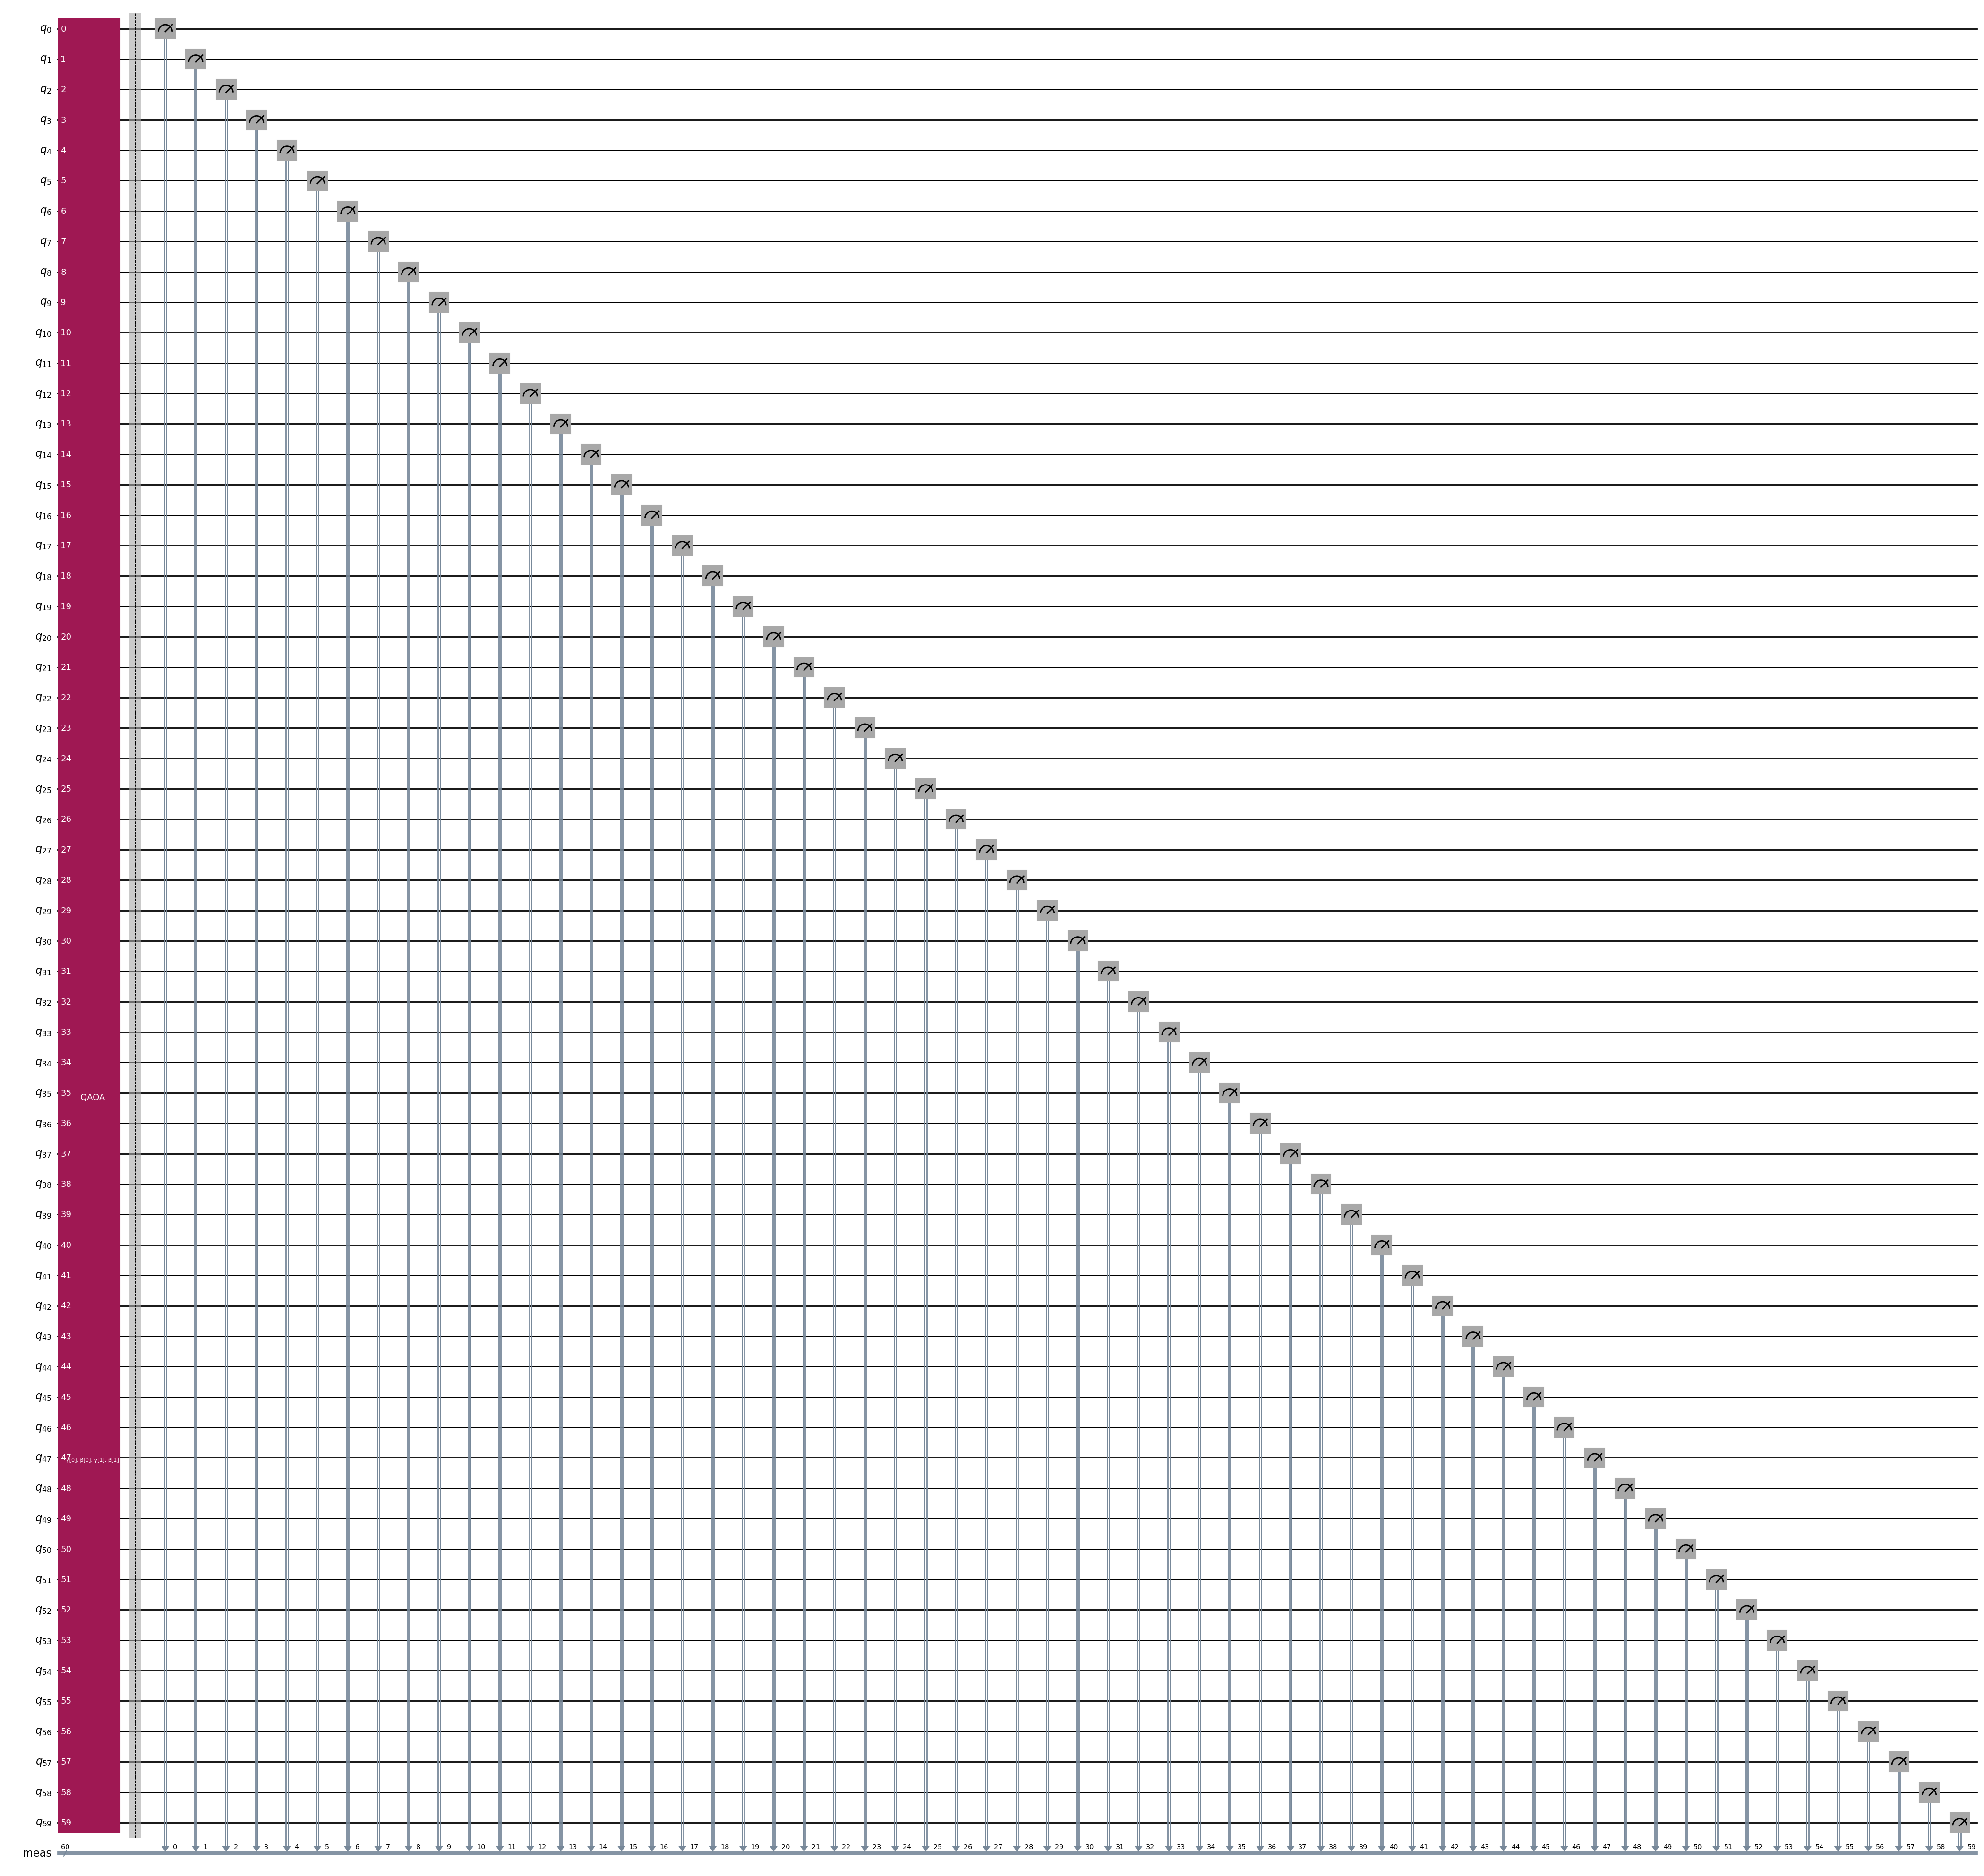

In [ ]:
from qiskit.circuit.library import QAOAAnsatz

cost_hamiltonian = out["cost_operator"]
ansatz = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
ansatz.measure_all()
ansatz.draw("mpl",fold=-1)